Warning message:
"Keys should be one or more alphanumeric characters followed by an underscore, setting key from atac to atac_"
snapshotDate(): 2022-10-31



AnnotationHub with 1 record
# snapshotDate(): 2022-10-31
# names(): AH75011
# $dataprovider: Ensembl
# $species: Homo sapiens
# $rdataclass: EnsDb
# $rdatadateadded: 2019-05-02
# $title: Ensembl 98 EnsDb for Homo sapiens
# $description: Gene and protein annotations for Homo sapiens based on Ensem...
# $taxonomyid: 9606
# $genome: GRCh38
# $sourcetype: ensembl
# $sourceurl: http://www.ensembl.org
# $sourcesize: NA
# $tags: c("98", "AHEnsDbs", "Annotation", "EnsDb", "Ensembl", "Gene",
#   "Protein", "Transcript") 
# retrieve record with 'object[["AH75011"]]' 

downloading 1 resources

retrieving 1 resource

loading from cache

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels i

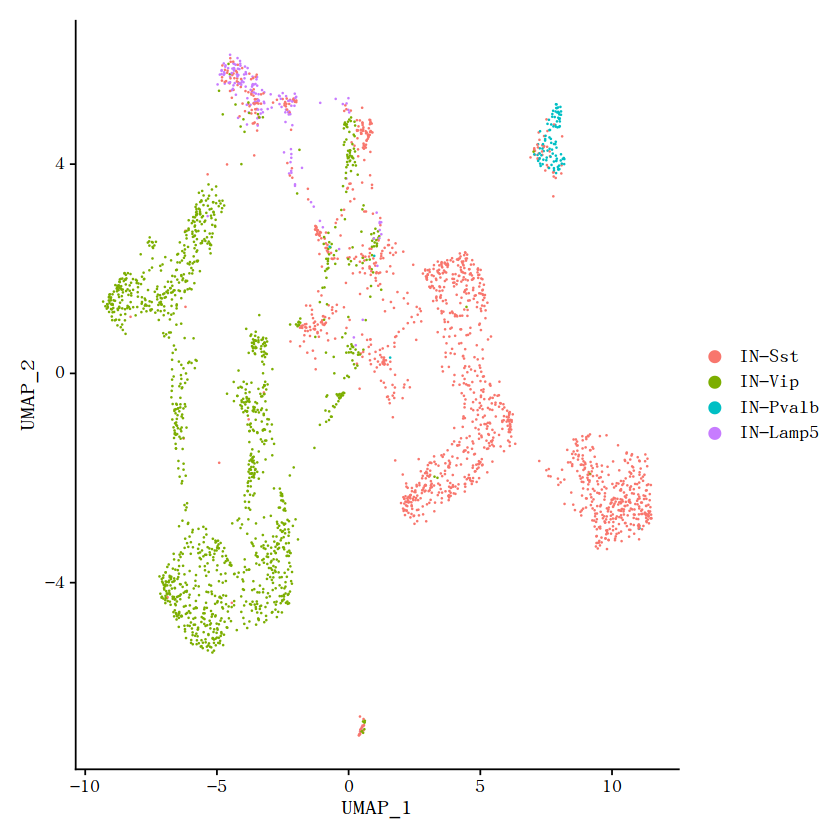

In [2]:
library(Seurat)
library(Signac)
library(ensembldb)
library(biovizBase)
library(AnnotationHub)
library(GenomicRanges)


RNA_count <- Matrix::readMM("./ComicGTN/data/MOGHE_brain/Neuron_type/IN_Gene_Cell.mtx")
ATAC_count <- Matrix::readMM("./ComicGTN/data/MOGHE_brain/Neuron_type/IN_Peak_Cell.mtx")
Gene_names <- read.table("./ComicGTN/data/MOGHE_brain/Neuron_type/IN_gene_names.tsv", header = FALSE, sep = ",")
Peak_names <- read.table("./ComicGTN/data/MOGHE_brain/Neuron_type/IN_peak_names.tsv", header = FALSE, sep = ",")
Cell_names <- read.table("./ComicGTN/data/MOGHE_brain/Neuron_type/IN_cell_names.tsv", header = FALSE, sep = ",")
Cell_types <- read.table("./ComicGTN/data/MOGHE_brain/Neuron_type/IN_cell_types.tsv", header = FALSE, sep = ",")


RNA_count <- as(RNA_count, "dgCMatrix")
colnames(RNA_count) <- Cell_names$V1
rownames(RNA_count) <- Gene_names$V1
ATAC_count <- as(ATAC_count, "dgCMatrix")
colnames(ATAC_count) <- Cell_names$V1
rownames(ATAC_count) <- Peak_names$V1
rownames(Cell_types) <- Cell_names$V1


IN_chrom_assay <- CreateChromatinAssay(counts = ATAC_count, sep = c(":", "-"))
IN_cluster <- CreateSeuratObject(IN_chrom_assay, assay = "ATAC")
IN_cluster <- IN_cluster[, intersect(colnames(RNA_count), colnames(IN_cluster))]
IN_cluster[["RNA"]] <- CreateAssayObject(counts = RNA_count[, intersect(colnames(RNA_count), colnames(IN_cluster))])
IN_cluster@meta.data$cell_types <- Cell_types$V1
std_chr <- GenomeInfoDb::standardChromosomes(granges(IN_cluster))
peaks.keep <- as.character(seqnames(granges(IN_cluster))) %in% as.vector(std_chr)
IN_cluster <- IN_cluster[as.vector(peaks.keep), ]
IN_cluster <- IN_cluster[, intersect(colnames(RNA_count), colnames(IN_cluster))]
IN_cluster[["RNA"]] <-CreateAssayObject(counts = RNA_count[, intersect(colnames(RNA_count), colnames(IN_cluster))])

ah <- AnnotationHub(localHub = FALSE)
query(ah, "EnsDb.Hsapiens.v98")
ensdb_v98 <- ah[["AH75011"]]
annotations <-GetGRangesFromEnsDb(ensdb = ensdb_v98)
seqlevels(annotations) <-paste0('chr', seqlevels(annotations))
genome(annotations) <-"hg38"
Annotation(IN_cluster) <- annotations


DefaultAssay(IN_cluster) <- "ATAC"
IN_cluster <- RunTFIDF(IN_cluster)
IN_cluster <- FindTopFeatures(IN_cluster, min.cutoff = "q5")
IN_cluster <-RunSVD(IN_cluster)
IN_cluster <-FindNeighbors(object = IN_cluster, reduction = "lsi", dims = 2:50)
IN_cluster <-FindClusters(object = IN_cluster, verbose = FALSE, algorithm = 3)
IN_cluster <-RunUMAP(IN_cluster, dims = 2:50, reduction = "lsi")
Idents(IN_cluster) <- Cell_types
DimPlot(IN_cluster, pt.size = 0.1)



载入需要的程辑包：BSgenome

载入需要的程辑包：Biostrings

载入需要的程辑包：XVector


载入程辑包：‘Biostrings’


The following object is masked from ‘package:base’:

    strsplit


载入需要的程辑包：rtracklayer

Building motif matrix

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL383518v1_alt, chr1_GL383519v1_alt, chr1_GL383520v2_alt, chr1_KI270759v1_alt, chr1_KI270760v1_alt, chr1_KI270761v1_alt, chr1_KI270762v1_alt, chr1_KI270763v1_alt, chr1_KI270764v1_alt, chr1_KI270765v1_alt, chr1_KI270766v1_alt, chr1_KI270892v1_alt, chr2_GL383521v1_alt, chr2_GL383522v1_alt, chr2_GL582966v2_alt, chr2_KI270767v1_alt, chr2_KI270768v1_alt, chr2_KI270769v1_alt, chr2_KI270770v1_alt, chr2_KI270771v1_alt, chr2_KI270772v1_alt, chr2_KI270773v1_alt, chr2_KI270774v1_alt, chr2_KI270775v1_alt, chr2_KI270776v1_alt, chr2_KI270893v1_alt, chr2_KI270894v1_alt, chr3_GL383526v1_alt, chr3_JH636055v2_alt, chr3_KI270777v1_alt, chr3_KI270778v1_alt, chr3_KI270779

Finding motif positions

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL383518v1_alt, chr1_GL383519v1_alt, chr1_GL383520v2_alt, chr1_KI270759v1_alt, chr1_KI270760v1_alt, chr1_KI270761v1_alt, chr1_KI270762v1_alt, chr1_KI270763v1_alt, chr1_KI270764v1_alt, chr1_KI270765v1_alt, chr1_KI270766v1_alt, chr1_KI270892v1_alt, chr2_GL383521v1_alt, chr2_GL383522v1_alt, chr2_GL582966v2_alt, chr2_KI270767v1_alt, chr2_KI270768v1_alt, chr2_KI270769v1_alt, chr2_KI270770v1_alt, chr2_KI270771v1_alt, chr2_KI270772v1_alt, chr2_KI270773v1_alt, chr2_KI270774v1_alt, chr2_KI270775v1_alt, chr2_KI270776v1_alt, chr2_KI270893v1_alt, chr2_KI270894v1_alt, chr3_GL383526v1_alt, chr3_JH636055v2_alt, chr3_KI270777v1_alt, chr3_KI270778v1_alt, chr3_KI270779v1_alt, chr3_KI270780v1_alt, chr3_KI270781v1_alt, chr3_KI270782v1_alt, chr3_KI270783v1_alt, chr3_KI270784v1_alt, chr3_KI270895v1_alt, chr3_KI270924v1_alt, chr3_KI270934v1

Creating Motif object

Warning message in RegionStats.default(object = regions, genome = genome, verbose = verbose, :
“Not all seqlevels present in supplied genome”
Selecting background regions to match input sequence characteristics

Matching GC.percent distribution

Testing motif enrichment in 850 regions



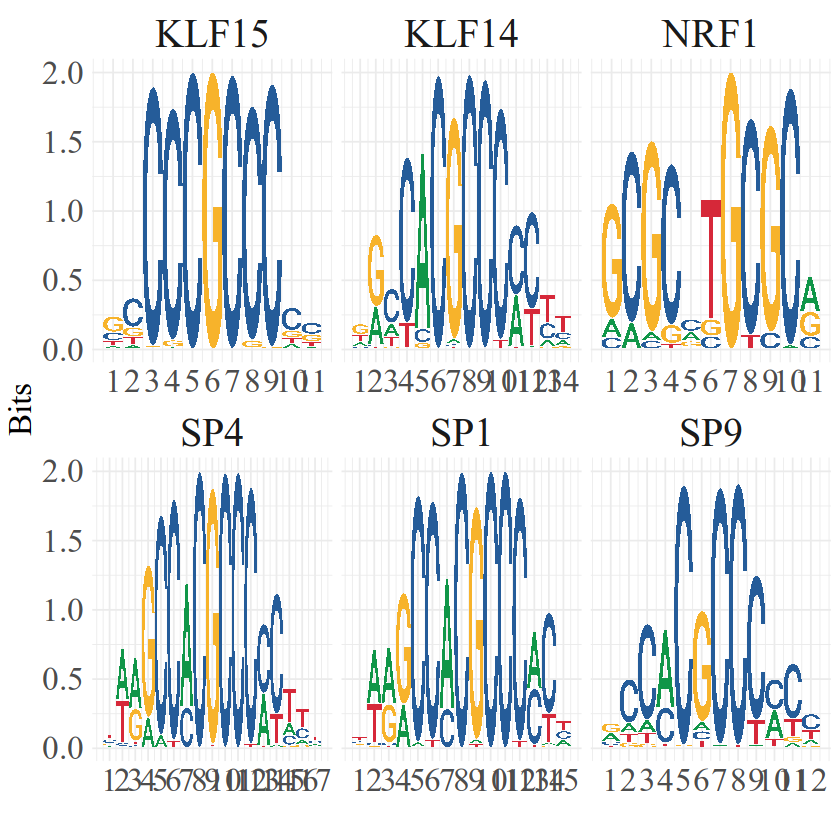

In [2]:
library(ggplot2)
library(TFBSTools)
library(patchwork)
library(ggseqlogo)
library(JASPAR2020)
library(BSgenome.Hsapiens.UCSC.hg38)


pfm <- getMatrixSet(x = JASPAR2020, opts = list(collection = "CORE", tax_group = "vertebrates", all_versions = FALSE))
DefaultAssay(IN_cluster) <- "ATAC"
IN_cluster <- AddMotifs(object = IN_cluster, genome = BSgenome.Hsapiens.UCSC.hg38, pfm = pfm)
da_peaks <- FindMarkers(object = IN_cluster, ident.1 = "IN-Lamp5",ident.2 = "IN-Sst", only.pos = TRUE,
                                          test.use = "LR", min.pct = 0.05, latent.vars = "nCount_ATAC")
top.da.peak <- rownames(da_peaks[da_peaks$p_val < 0.005 & da_peaks$pct.1 > 0.2, ])
enriched.motifs <-FindMotifs(object = IN_cluster, features = top.da.peak)
write.csv(enriched.motifs, "./ComicGTN/data/MOGHE_brain/Neuron_type/Enriched_motif/Sst_Lamp5.csv", row.names = FALSE)


p <- MotifPlot(object = IN_cluster, motifs = head(rownames(enriched.motifs)), stack_width=1)
p + theme_minimal()+theme(text = element_text(family = "Times New Roman", size = 30),
                                                axis.title = element_text(size = 20), axis.text = element_text(size = 20))

Computing GC bias per region

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL383518v1_alt, chr1_GL383519v1_alt, chr1_GL383520v2_alt, chr1_KI270759v1_alt, chr1_KI270760v1_alt, chr1_KI270761v1_alt, chr1_KI270762v1_alt, chr1_KI270763v1_alt, chr1_KI270764v1_alt, chr1_KI270765v1_alt, chr1_KI270766v1_alt, chr1_KI270892v1_alt, chr2_GL383521v1_alt, chr2_GL383522v1_alt, chr2_GL582966v2_alt, chr2_KI270767v1_alt, chr2_KI270768v1_alt, chr2_KI270769v1_alt, chr2_KI270770v1_alt, chr2_KI270771v1_alt, chr2_KI270772v1_alt, chr2_KI270773v1_alt, chr2_KI270774v1_alt, chr2_KI270775v1_alt, chr2_KI270776v1_alt, chr2_KI270893v1_alt, chr2_KI270894v1_alt, chr3_GL383526v1_alt, chr3_JH636055v2_alt, chr3_KI270777v1_alt, chr3_KI270778v1_alt, chr3_KI270779v1_alt, chr3_KI270780v1_alt, chr3_KI270781v1_alt, chr3_KI270782v1_alt, chr3_KI270783v1_alt, chr3_KI270784v1_alt, chr3_KI270895v1_alt, chr3_KI270924v1_alt, chr3_KI270

Selecting background regions

Computing deviations from background

Constructing chromVAR assay



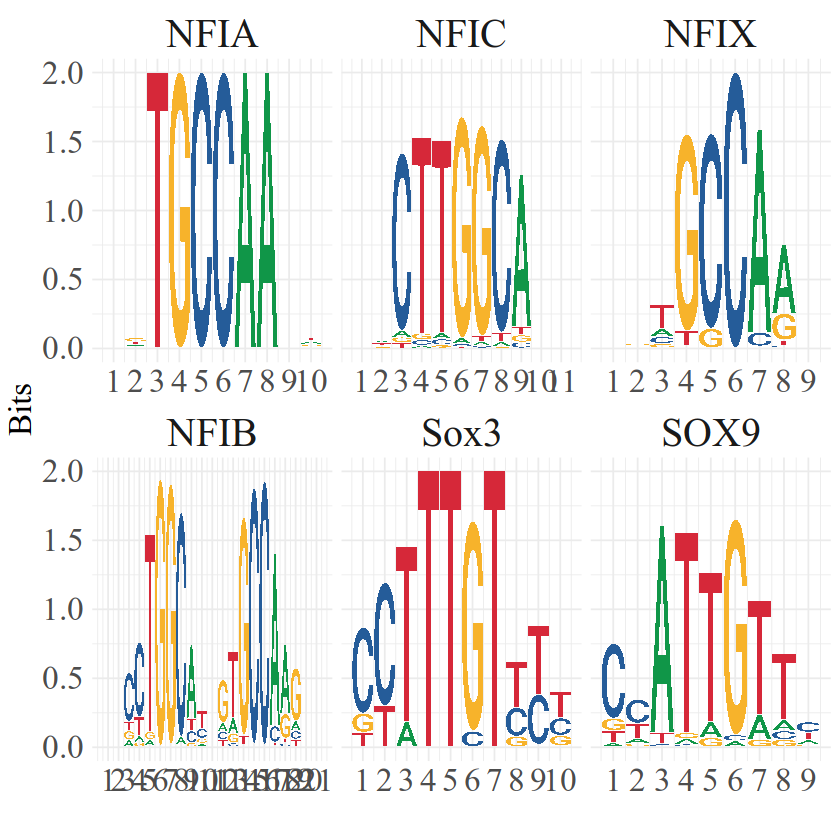

In [16]:
IN_cluster <- RunChromVAR(object = IN_cluster, genome = BSgenome.Hsapiens.UCSC.hg38)
DefaultAssay(IN_cluster) <- "chromvar"
differential.activity <- FindMarkers(object = IN_cluster, ident.1 = "IN-Lamp5", ident.2 = "IN-Sst", 
                                                         only.pos = TRUE, mean.fxn = rowMeans, fc.name = "avg_diff")
p <- MotifPlot(object = IN_cluster, motifs = head(rownames(differential.activity)), assay = "ATAC")
p + theme_minimal()+theme(text = element_text(family = "Times New Roman", size = 30),
                                                axis.title = element_text(size = 20), axis.text = element_text(size = 20))
ggsave("./ComicGTN/data/MOGHE_brain/Neuron_type/Enriched_motif/Sst_Lamp5_chromvar.png", plot = p, bg = "white", 
            family = "Times New Roman", width = 8, height = 6, dpi = 600)
write.csv(as.data.frame(IN_cluster$chromvar@data), file = "./ComicGTN/data/MOGHE_brain/Neuron_type/Enriched_motif/Sst_Lamp5_chromvar_score.csv", 
               row.names = TRUE, quote = FALSE)